In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('/content/train.csv')

смотрим размер датасетов

In [5]:
train_path = '/content/train.csv'
test_path = '/content/test.csv'

test_df = pd.read_csv(test_path)
train_df = pd.read_csv(train_path)

print(train_df.shape, '\n', test_df.shape)

(15000, 20) 
 (10000, 19)


посмотрим, сбалансированы ли классы у таргет признака

In [14]:
train_df["Status"].value_counts()

,count
Status,
C,10042
D,4611
CL,347


видим, что класс C сильно перевешивает класс CL

теперь посмотрим сколько нанов, какие типы данныхъ сод-ся в датасете

In [52]:
print("Train Data Info:")
train_df.info()

print("\nTest Data Info:")
test_df.info()

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     15000 non-null  int64  
 1   N_Days                 15000 non-null  float64
 2   Drug                   8410 non-null   object 
 3   Age                    15000 non-null  float64
 4   Sex                    15000 non-null  object 
 5   Ascites                8419 non-null   object 
 6   Hepatomegaly           8409 non-null   object 
 7   Spiders                8409 non-null   object 
 8   Edema                  15000 non-null  object 
 9   Bilirubin              15000 non-null  float64
 10  Cholesterol            6527 non-null   float64
 11  Albumin                15000 non-null  float64
 12  Copper                 8300 non-null   float64
 13  Alk_Phos               8404 non-null   float64
 14  SGOT                   8402 non-null 

In [7]:
import seaborn as sns

num_features = ["N_Days", "Age", "Bilirubin", "Cholesterol", "Albumin", "Copper", "Alk_Phos", "SGOT", "Tryglicerides",
                "Platelets", "Prothrombin"]

print("Train Data describe:")
cm = sns.light_palette("green", as_cmap=True)
display(train_df[num_features].describe().T.style.background_gradient(cmap=cm))

print("\nTest Data describe:")
display(test_df[num_features].describe().T.style.background_gradient(cmap=cm))

Train Data describe:


,count,mean,std,min,25%,50%,75%,max
N_Days,15000.000000,1972.321333,1409.311534,10.000000,1092.000000,1785.000000,2635.000000,34302.000000
Age,15000.000000,19377.047467,3635.775702,1072.000000,16728.000000,19724.000000,22574.000000,39015.000000
Bilirubin,15000.000000,1.869335,2.751488,0.300000,0.600000,0.900000,1.800000,28.000000
Cholesterol,6527.000000,326.919258,173.228567,108.000000,242.000000,280.000000,361.000000,1776.000000
Albumin,15000.000000,3.524895,0.374083,1.960000,3.290000,3.580000,3.770000,4.680000
Copper,8300.000000,76.296614,77.936581,0.900000,31.000000,52.000000,89.000000,598.000000
Alk_Phos,8404.000000,1639.489089,1828.852487,120.900000,718.000000,1072.000000,1664.000000,18993.400000
SGOT,8402.000000,106.425993,50.393832,0.900000,71.000000,97.650000,133.300000,601.350000
Tryglicerides,6478.000000,111.364464,51.178377,5.000000,80.000000,99.000000,133.000000,598.000000
Platelets,14443.000000,252.444714,93.622032,28.000000,181.000000,249.000000,311.000000,721.000000



Test Data describe:


,count,mean,std,min,25%,50%,75%,max
N_Days,10000.000000,1962.070100,1269.339714,41.000000,1092.000000,1785.000000,2635.000000,25569.000000
Age,10000.000000,19249.829500,3655.562757,108.000000,16463.000000,19358.000000,22336.000000,34241.000000
Bilirubin,10000.000000,1.846600,2.759273,0.300000,0.600000,0.900000,1.800000,28.000000
Cholesterol,4454.000000,328.852268,179.056934,120.000000,239.000000,280.000000,364.000000,1792.000000
Albumin,10000.000000,3.544344,1.892072,1.960000,3.290000,3.580000,3.770000,189.000000
Copper,5643.000000,75.771575,76.191731,1.000000,31.000000,52.000000,89.000000,642.000000
Alk_Phos,5707.000000,1650.257435,1844.176485,14.380000,728.000000,1074.000000,1688.500000,19246.800000
SGOT,5706.000000,106.031830,49.882763,0.900000,71.000000,97.650000,130.200000,601.350000
Tryglicerides,4414.000000,110.140236,50.928390,11.000000,78.000000,98.000000,130.750000,598.000000
Platelets,9611.000000,255.125793,98.605477,62.000000,190.000000,251.000000,312.000000,3500.000000


array([[<Axes: title={'center': 'Bilirubin'}>,
        <Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'Copper'}>],
       [<Axes: title={'center': 'Alk_Phos'}>,
        <Axes: title={'center': 'SGOT'}>,
        <Axes: title={'center': 'Tryglicerides'}>],
       [<Axes: title={'center': 'Platelets'}>,
        <Axes: title={'center': 'Prothrombin'}>, <Axes: >]], dtype=object)

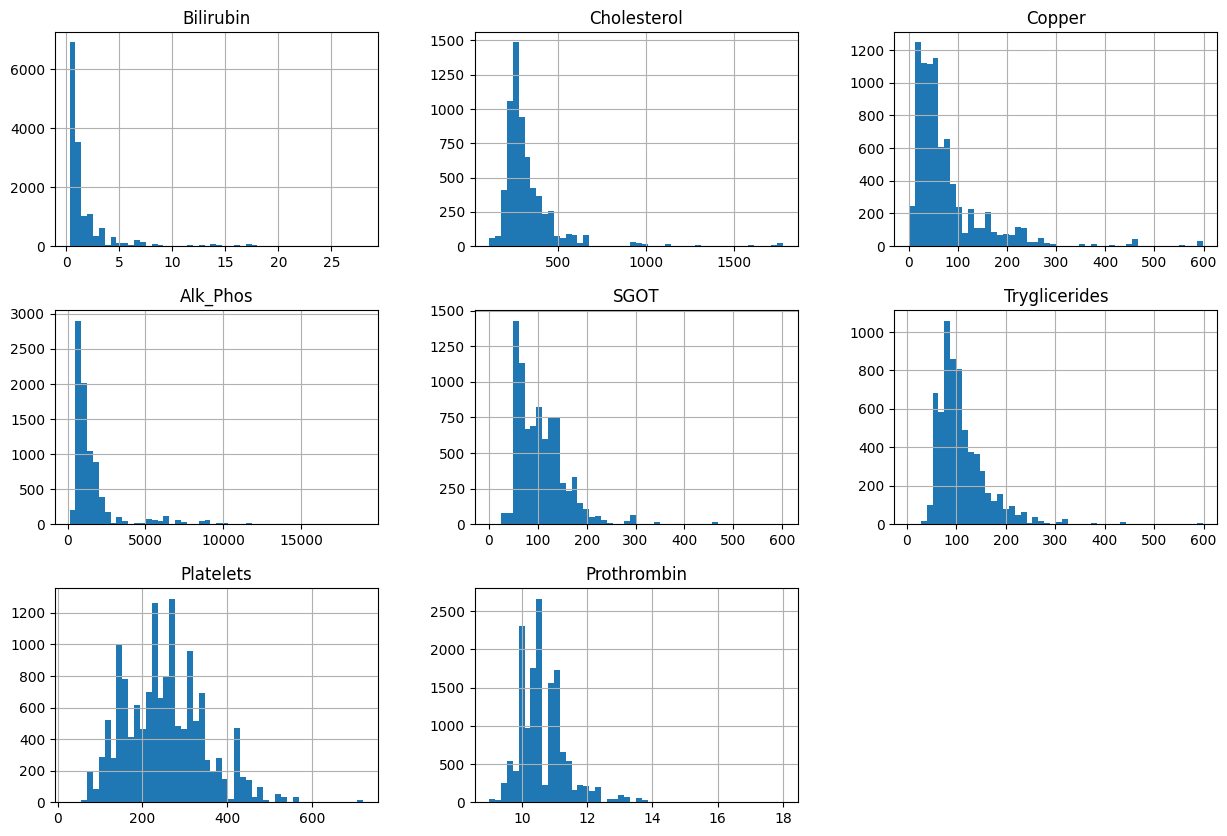

In [ ]:
num_cols = ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
df[num_cols].hist(figsize=(15, 10), bins=50)

In [ ]:
from scipy.stats import skew

num_cols = ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
for col in num_cols:
    print(f"{col}: {skew(df[col].dropna()):.2f}")

Bilirubin: 4.19
Cholesterol: 4.46
Copper: 3.05
Alk_Phos: 3.36
SGOT: 1.87
Tryglicerides: 2.33
Platelets: 0.53
Prothrombin: 1.34


In [ ]:
df.drop('id', axis=1, inplace=True)

df['Age_years'] = df['Age'] / 365.25
df.drop('Age', axis=1, inplace=True)

cat_cols = ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders']
for col in cat_cols:
    df[col] = df[col].fillna('Missing')

In [ ]:
num_cols = ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT',
            'Tryglicerides', 'Platelets', 'Prothrombin']

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

Bilirubin_log: 1.91
Cholesterol_log: 2.56
Copper_log: 0.40
Alk_Phos_log: 1.93
SGOT_log: -0.03
Tryglicerides_log: 0.85
Prothrombin_log: 1.02


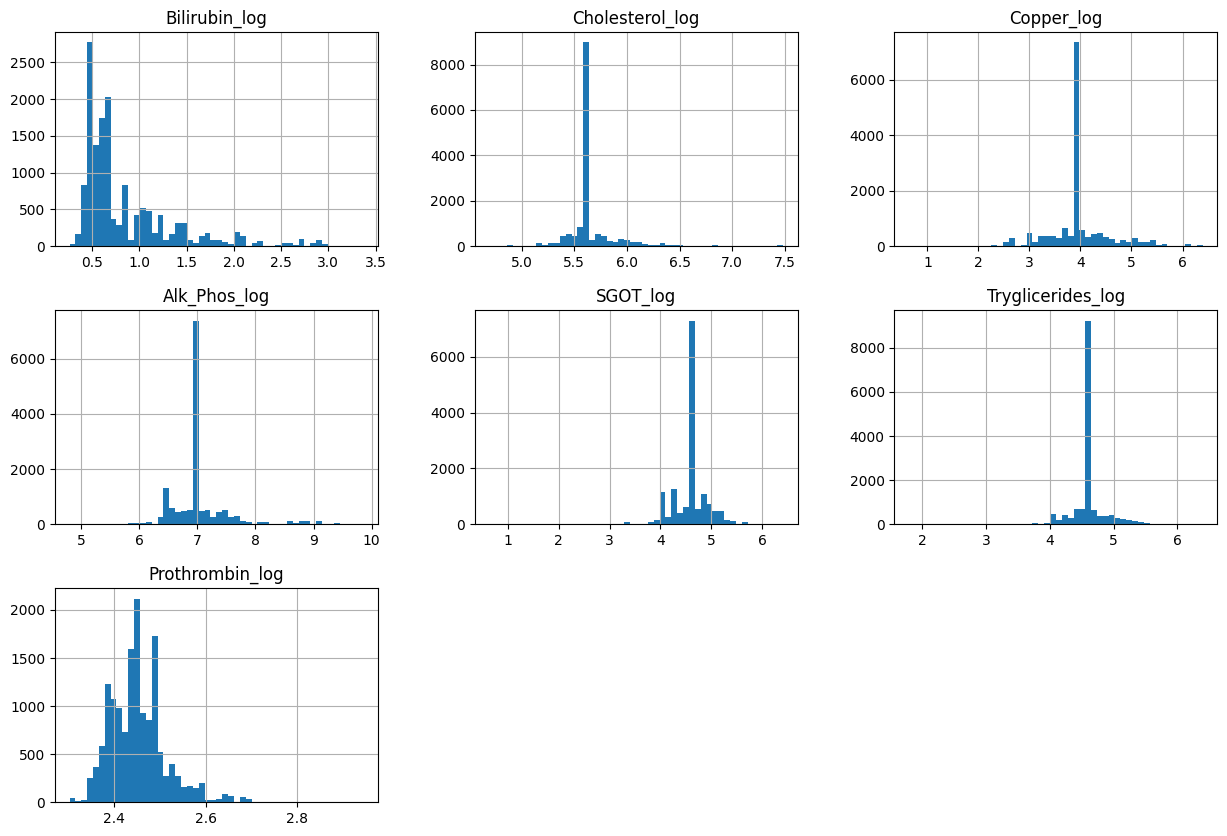

In [ ]:
skewed_cols = ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Prothrombin']
for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])

log_cols = ['Bilirubin_log', 'Cholesterol_log', 'Copper_log', 'Alk_Phos_log', 'SGOT_log', 'Tryglicerides_log', 'Prothrombin_log']

df[log_cols].hist(figsize=(15, 10), bins=50)
for col in log_cols:
    print(f"{col}: {skew(df[col].dropna()):.2f}")

<Axes: >

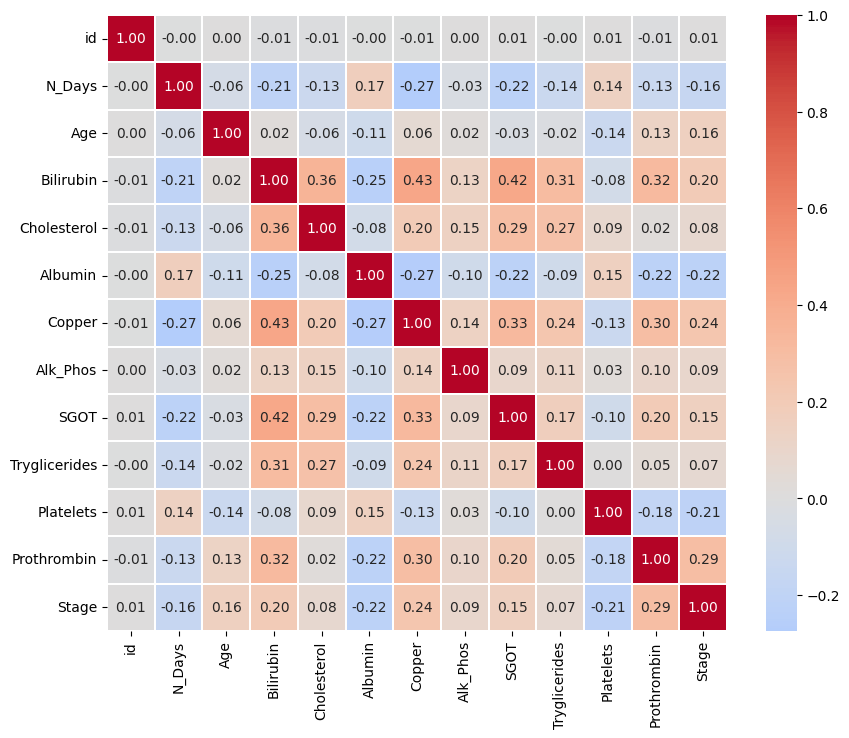

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(train_df[num_cols].corr(), cmap="coolwarm", center=0, linewidth=0.1, annot=True, fmt=".2f",)

сильной коллинеарности нет (самая большая корреляция 0.43), а значит при обучении будем использовать все признаки. также можем заметить, что Bilirubin отрицательно коррелирует с Albumin - а это означает их соотношение может усиливать сигнал тяжести заболевания, так как оба признака яв-ся показателями функции печени.

<Axes: xlabel='Status', ylabel='Prothrombin'>

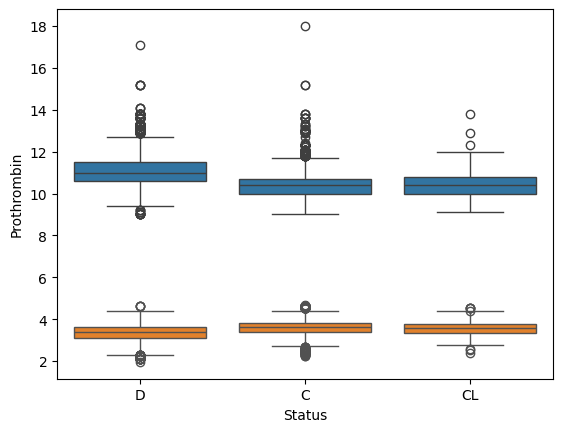

In [30]:
sns.boxplot(x="Status", y="Prothrombin", data=train_df)
sns.boxplot(x="Status", y="Albumin", data=train_df)

коробки сильно перекрываются, а значит различия между классами плохое

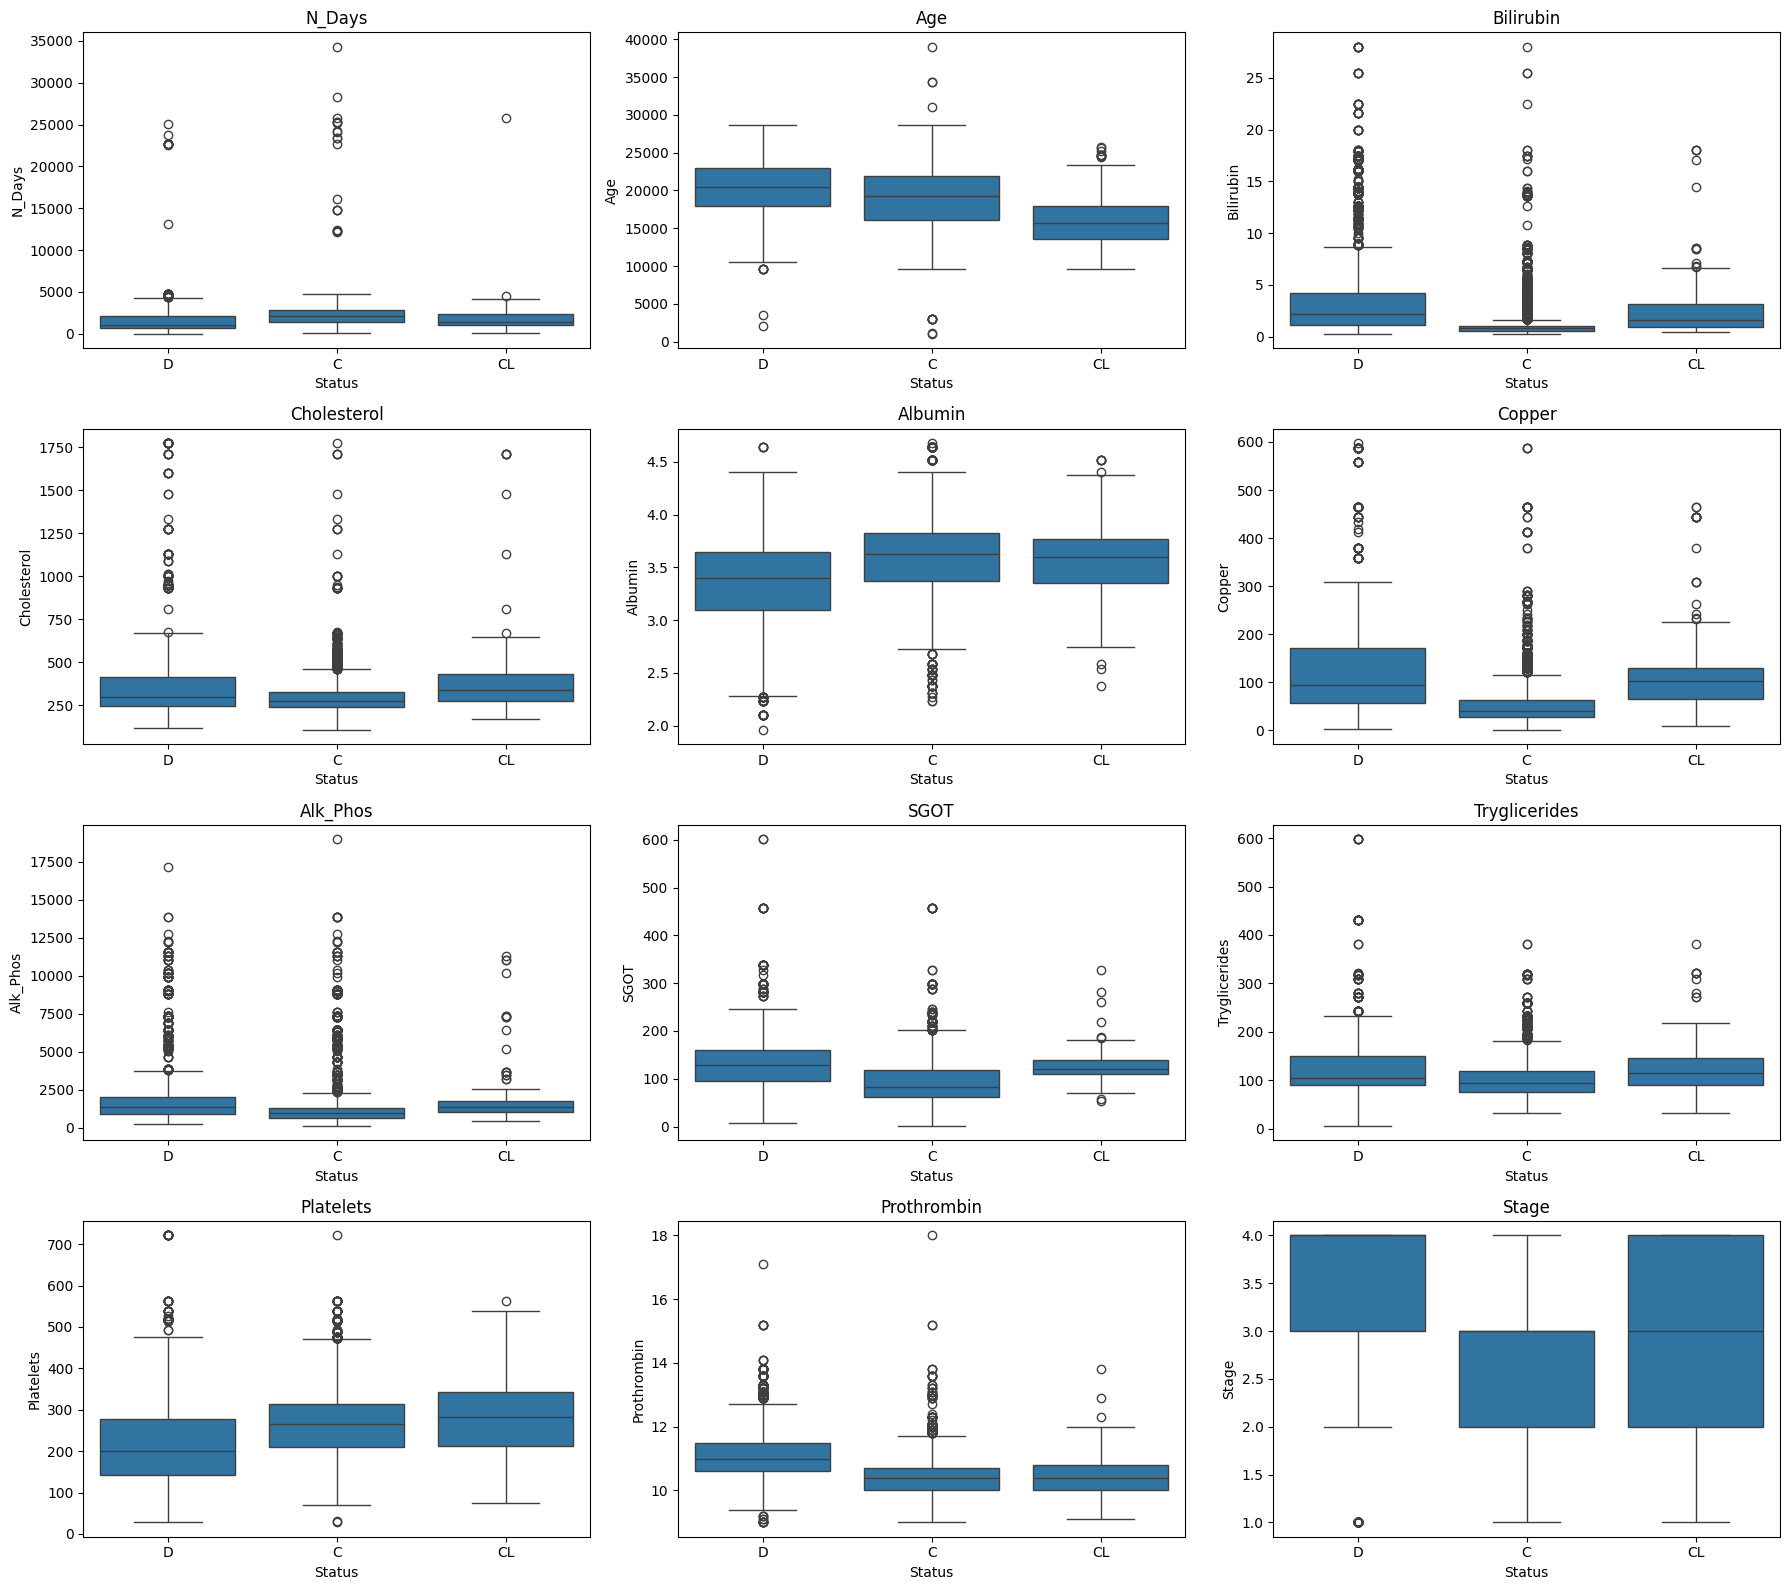

In [31]:
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
num_cols = [col for col in num_cols if col != "id"]

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x="Status", y=col, data=train_df, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

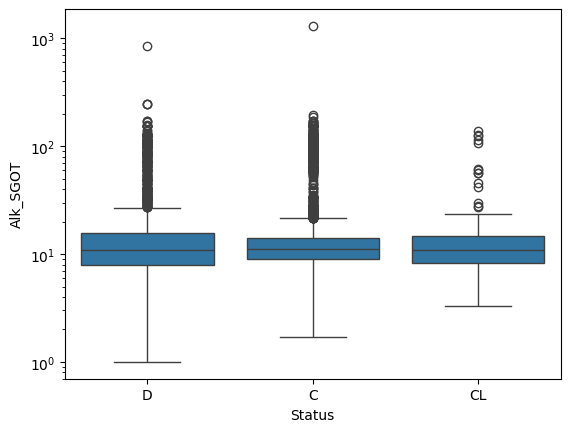

In [41]:
eps = 1e-6

train_df["Alk_SGOT"] = train_df["Alk_Phos"] / (train_df["SGOT"] + eps)
sns.boxplot(x="Status", y="Alk_SGOT", data=train_df)
plt.yscale('log')
plt.show()

новый признак не усилил разделение.

<Axes: xlabel='Status', ylabel='Platelets_Prothrombin'>

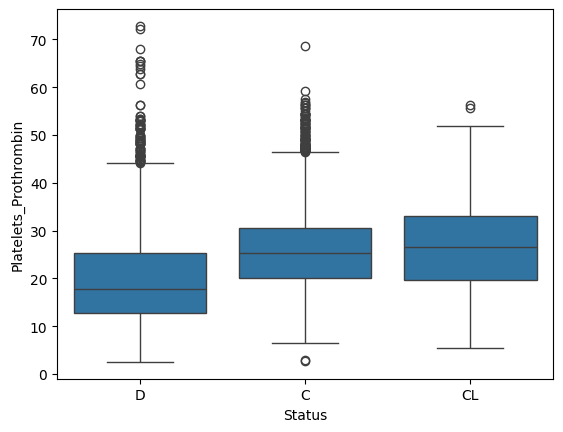

In [43]:
train_df["Platelets_Prothrombin"] = train_df["Platelets"] / (train_df["Prothrombin"] + eps)
sns.boxplot(x="Status", y="Platelets_Prothrombin", data=train_df)


разделение чуть заметнее

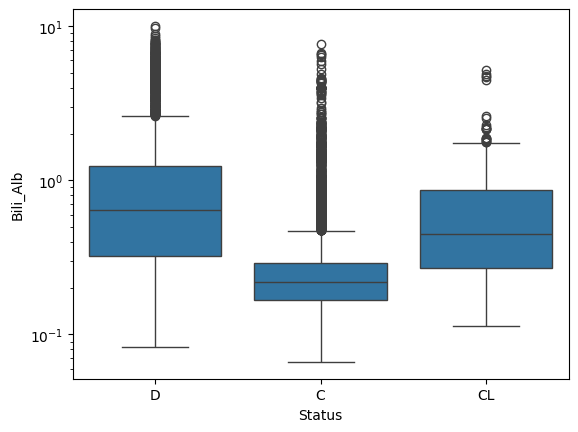

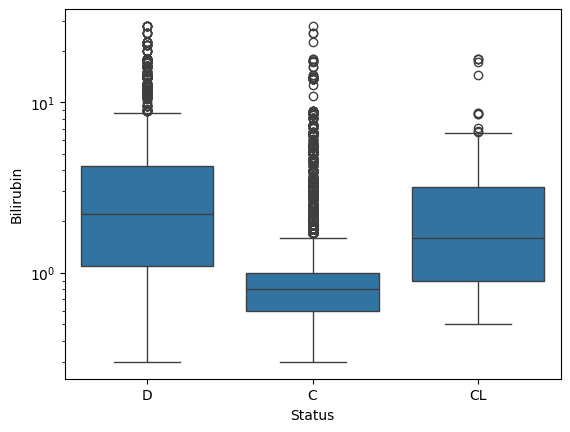

In [47]:
train_df["Bili_Alb"] = train_df["Bilirubin"] / (train_df["Albumin"] + eps)
sns.boxplot(x="Status", y="Bili_Alb", data=train_df)
plt.yscale('log')
plt.show()

sns.boxplot(x="Status", y="Bilirubin", data=train_df)
plt.yscale('log')
plt.show()

новый признак почти не отличается от старого Bilirubin, скорее всего он не даст большого прироста

также есть крутая библиотека для анализа данных

In [ ]:
# !pip install -U ydata-profiling

In [50]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, title="отчет по данным")

In [ ]:
# profile.to_notebook_iframe()